### Imports:

In [2]:
# %matplotlib widget
%matplotlib inline
import os
import pandas as pd
import vis_detect_helpers_v7 as hp
import photom_helpers as ph
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load and preprocess raw data into dataframe:

In [73]:
mouse_dir = 'Data'
session_settings_files, trials_files = hp.get_session_files(mouse_dir, timestamp='20241004')
session_data = hp.process_session_data(session_settings_files, trials_files)

number of files: session_settings:  1 trials:  1
******************   NEW   SESSION   ******************
mouse_id is:  021
session_date is:  20241004
session_time is:  110421
session timestamp is:  2024-10-04 11:04:21
len iti_values: 806
auto rewd is:  0
punishment is:  end_trial
protocol is:  4
unique outcomes are:  ['FA' 'Hit' 'Miss' 'Ref' 'abort']
unique laser states are:  [False  True]


### context and color mapping setup:

In [74]:
sns.set_context('notebook')  # other options for context include paper (smaller), talk (bigger), and poster (biggest). Can also add 'scale' argument for axis text size
outcome_palette = {
    'Hit': 'green',
    'FA': 'red',
    'abort': 'black',
    'Miss': 'purple',
    'Ref': 'blue'
}

outcome_order = ['Hit', 'FA', 'Miss', 'abort', 'Ref']

laser_palette = {
    True: 'blue',
    False: 'gray'
}

### OUTCOME SEQUENCE

In [75]:
fa_laser_df = session_data[(session_data['outcomes'] == 'FA') & (session_data['laser_states'] == True)]
fa_no_laser_df = session_data[(session_data['outcomes'] == 'FA') & (session_data['laser_states'] == False)]

In [76]:
fa_laser_df.describe()

,session_timestamp,auto_rewd,protocol,iti_values,change_times,change_sizes_TF,reaction_times,reaction_times_from_reference_start
count,10,10.0,10.0,10.000000,10.000000,10.000000,10.000000,10.000000
mean,2024-10-04 11:04:21,0.0,4.0,3.361439,7.800000,1.480000,4.169800,7.531239
min,2024-10-04 11:04:21,0.0,4.0,3.032466,6.245000,1.250000,0.393000,3.880568
25%,2024-10-04 11:04:21,0.0,4.0,3.144964,6.670000,1.275000,2.995500,6.238383
50%,2024-10-04 11:04:21,0.0,4.0,3.238985,7.020000,1.350000,3.821500,7.279718
75%,2024-10-04 11:04:21,0.0,4.0,3.488141,7.945000,1.500000,5.848500,9.095574
max,2024-10-04 11:04:21,0.0,4.0,3.920673,11.695000,2.000000,7.503000,10.627291
std,NaN,0.0,0.0,0.298407,1.890392,0.288868,2.182192,2.256575


In [77]:
fa_no_laser_df.describe()

,session_timestamp,auto_rewd,protocol,iti_values,change_times,change_sizes_TF,reaction_times,reaction_times_from_reference_start
count,44,44.0,44.0,44.000000,44.000000,44.000000,44.000000,44.000000
mean,2024-10-04 11:04:21,0.0,4.0,3.612761,8.627955,1.651136,5.502568,9.115329
min,2024-10-04 11:04:21,0.0,4.0,3.040306,6.095000,1.000000,0.012000,3.899745
25%,2024-10-04 11:04:21,0.0,4.0,3.226474,6.932500,1.250000,3.847000,7.579333
50%,2024-10-04 11:04:21,0.0,4.0,3.518099,8.220000,1.350000,5.384000,8.748118
75%,2024-10-04 11:04:21,0.0,4.0,3.717082,9.557500,1.500000,7.439750,10.892734
max,2024-10-04 11:04:21,0.0,4.0,5.391233,14.095000,4.000000,10.847000,15.131233
std,NaN,0.0,0.0,0.565431,2.033011,0.896666,2.678445,2.653336


In [78]:
def plot_outcome_sequence(session_data):
    # Extract outcomes from session_data
    outcomes = session_data['outcomes']
    
    
    # Create a DataFrame suitable for seaborn
    outcome_df = pd.DataFrame({
        'Trial': range(len(outcomes)),
        'Outcome': outcomes
    })
    
    # Create the plot
    # plt.figure(figsize=(10, 2))
    sns.scatterplot(data=outcome_df, x='Trial', y='Outcome', hue='Outcome', palette=outcome_palette, marker='|', s=200, alpha=0.7, hue_order=outcome_order)
    
    # Customize the plot
    plt.xlabel('Trial Number')
    plt.ylabel('Outcome')
    plt.title('Sequence of Outcomes')
    plt.yticks([])  # Hide y-axis ticks
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1), frameon=False, fontsize='small')
    sns.despine()
    # plt.show()

### FREQUENCY AND FRACTION OF EACH OUTCOME

In [79]:
def plot_outcome_distribution(ax, session_data, outcome_palette):
    # Extract outcomes from session_data
    outcomes = session_data['outcomes']
    
    # Create a DataFrame of outcome counts
    outcome_counts = outcomes.value_counts().reset_index()
    outcome_counts.columns = ['Outcome', 'Frequency']
    
    # Calculate the fraction of each outcome
    outcome_counts['Fraction'] = outcome_counts['Frequency'] / outcome_counts['Frequency'].sum()
    ax.set_title('Frequency and Fraction of Each Outcome')
    # Plot the frequency
    sns.barplot(data=outcome_counts, x='Outcome', y='Frequency', palette=outcome_palette, ax=ax, hue_order=outcome_order)
    
    
    
    # Create a second y-axis for the fraction
    ax2 = ax.twinx()
    
    # Plot the fraction with a secondary y-axis
    sns.barplot(data=outcome_counts, x='Outcome', y='Fraction', ax=ax2, alpha=0)
    
    # Hide the top spines
    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(True)
    # plt.show()

### PERFORMANCE

In [80]:
def plot_session_performance(session_data):
    # Calculate session performance for laser on and laser off trials
    perf_laser_on = ph.calculate_session_performance(session_data[session_data['laser_states'] == 1])
    perf_laser_off = ph.calculate_session_performance(session_data[session_data['laser_states'] == 0])

    # Create DataFrames
    perf_laser_on_df = pd.DataFrame.from_dict(perf_laser_on, orient='index', columns=['performance', 'ci95'])
    perf_laser_off_df = pd.DataFrame.from_dict(perf_laser_off, orient='index', columns=['performance', 'ci95'])

    # Create the point plot
    sns.pointplot(x=perf_laser_on_df.index, y='performance', data=perf_laser_on_df, color='blue', label='Laser On')
    sns.pointplot(x=perf_laser_off_df.index, y='performance', data=perf_laser_off_df,color = 'gray', label='Laser Off')

    # Add error bars
    plt.errorbar(x=perf_laser_on_df.index.astype('str'), y=perf_laser_on_df['performance'], yerr=perf_laser_on_df['ci95'], capsize=3)
    plt.errorbar(x=perf_laser_off_df.index.astype('str'), y=perf_laser_off_df['performance'], yerr=perf_laser_off_df['ci95'], capsize=3, color='gray')

    # Customize the plot
    sns.despine()
    plt.xlabel('Change Size (TF)')
    plt.ylabel('Performance')
    plt.title(f'Performance by Change Size') # mouse: BG_{session_data["mouse_id"].iloc[0]}')
    plt.legend()
    # plt.tight_layout(pad=2.0)
    plt.show()

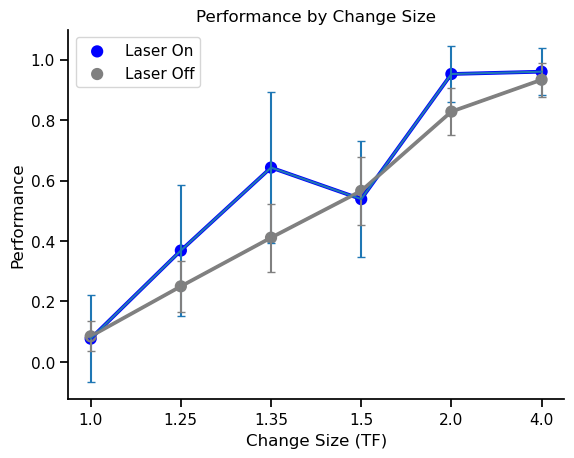

In [81]:
plot_session_performance(session_data)

### HIT REACTION TIMES BY CHANGE SIZE

In [82]:
def plot_hit_change_size_reaction_times(session_data):
    # Filter the DataFrame for 'Hit' outcomes
    hit_df = session_data[session_data['outcomes'] == 'Hit']
    
    # Create the point plot
    sns.pointplot(x='change_sizes_TF', y='reaction_times', data=hit_df, hue='laser_states',palette= laser_palette, errorbar=('ci', 95), capsize=0.15,errwidth=1.5)
    
    
    # Customize the plot
    plt.xlabel('Change Size (TF)')
    plt.ylabel('Reaction Time (s)')
    plt.title('Reaction Times by Change Size')
    sns.despine()
    plt.show()

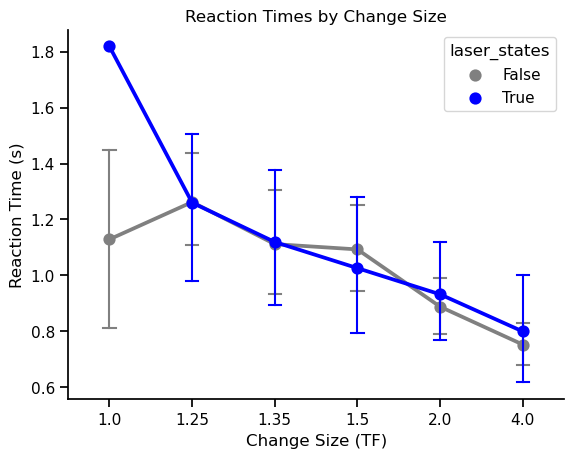

In [83]:
plot_hit_change_size_reaction_times(session_data)

### CUMULATIVE FRACTION OF EACH OUTCOME

In [14]:
def plot_cumulative_outcome_curve(session_data, outcome_palette):
    handles = []
    for outcome in outcome_order:
        outcome_df = session_data[session_data['outcomes'] == outcome]
        laser_true_df = outcome_df[outcome_df['laser_states'] == True]
        laser_false_df = outcome_df[outcome_df['laser_states'] == False]
        
        true_line = sns.ecdfplot(data=laser_true_df, x=laser_true_df.index, color=outcome_palette[outcome], alpha=0.7, linestyle='-')
        false_line = sns.ecdfplot(data=laser_false_df, x=laser_false_df.index, color=outcome_palette[outcome], alpha=0.7, linestyle='--')
        
        # Create a custom legend handle
        handle = plt.Line2D([0], [0], color=outcome_palette[outcome], label=outcome, linestyle='-')
        handle_dashed = plt.Line2D([0], [0], color=outcome_palette[outcome], label=f'{outcome} (Laser Off)', linestyle='--')
        handles.append(handle)
        handles.append(handle_dashed)
    
    plt.title('Outcomes cumulative curves')
    plt.xlabel('Trial Number')
    plt.ylabel('Cumulative Fraction')
    plt.legend(handles=handles, loc='upper left', fontsize='x-small', frameon=False)
    sns.despine()
    plt.show()

c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Conver

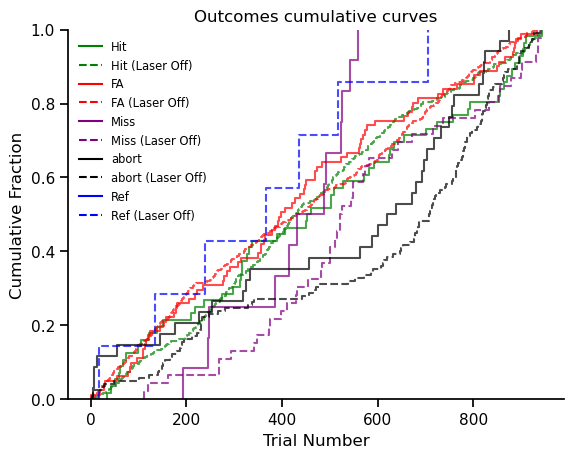

In [15]:
plot_cumulative_outcome_curve(session_data, outcome_palette)

### CUMULATIVE FRACTION HITS or MISSES ENCOUNTERED FOR DIFFERENT CHANGE TIMES

In [16]:
def plot_hit_change_encountered_ecdf(session_data, outcome_palette):
    # Filter the DataFrame for 'Hit' and 'Miss' outcomes
    hit_df = session_data[session_data['outcomes'] == 'Hit']
    unique_change_sizes = len(hit_df['change_sizes_TF'].unique())
    palette = sns.color_palette("magma", unique_change_sizes)
    # Create the ECDF plot
    sns.ecdfplot(x='change_times', data=hit_df, hue='change_sizes_TF', palette=palette, alpha=0.7)
    sns.ecdfplot(x='change_times', data=session_data, hue='change_sizes_TF',palette=palette, linestyle='--', alpha=0.7)
    
    # Customize the plot
    plt.xlabel('Change Time (s)')
    sns.despine()
    sns.move_legend(plt.gca(), loc = 'upper right',bbox_to_anchor=(1.2, 1),fontsize = 'x-small', frameon=False, title = '')
    plt.title('Hit change times encountered')

c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-

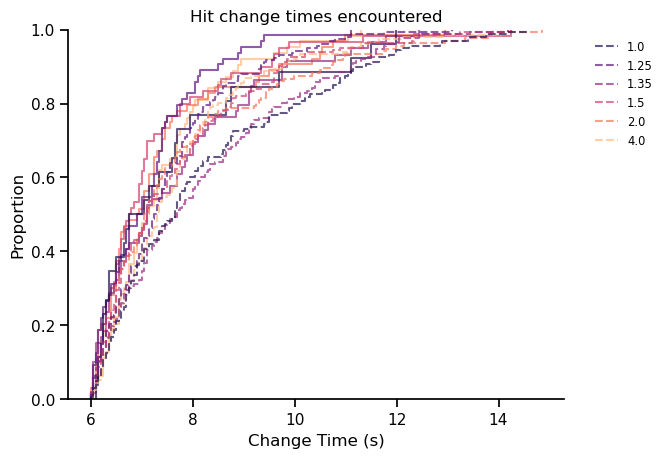

In [17]:
plot_hit_change_encountered_ecdf(session_data, outcome_palette)

### Show the ecdf for change sizes encountered for hits, compared to the potential changes that could be encountered for different change sizes in the session

In [18]:
def plot_change_encountered_ecdf(session_data, outcome_palette):
    # Filter the DataFrame for 'Hit' and 'Miss' outcomes
    change_encountered_df = session_data[(session_data['outcomes'] == 'Hit') | (session_data['outcomes'] == 'Miss')]
    
    # Create the ECDF plot
    sns.ecdfplot(x='change_times', data=change_encountered_df, hue='outcomes', palette=outcome_palette, alpha=0.7, hue_order=outcome_order)
    sns.ecdfplot(x='change_times', data=session_data, color='black', linestyle='--', alpha=0.5)
    
    # Customize the plot
    plt.xlabel('Change Time (s)')
    sns.despine()
    sns.move_legend(plt.gca(), loc = 'upper right',bbox_to_anchor=(1.2, 1),fontsize = 'x-small', frameon=False, title = '')
    plt.title('Change times encountered')
    # plt.legend(labels=['Hit', 'Miss'], loc='upper right', bbox_to_anchor=(1.2, 1), frameon=False, fontsize='x-small')
    # plt.show()

In [19]:
def plot_change_encountered_ecdf(session_data, outcome_palette):
    # Filter the DataFrame for 'Hit' and 'Miss' outcomes
    change_encountered_df = session_data[(session_data['outcomes'] == 'Hit') | (session_data['outcomes'] == 'Miss')]
    
    # Separate the data based on laser states
    laser_on_df = change_encountered_df[change_encountered_df['laser_states'] ==True]
    laser_off_df = change_encountered_df[change_encountered_df['laser_states'] == False]
    
    # Create the ECDF plots for laser on and off trials
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    sns.ecdfplot(x='change_times', data=laser_on_df, hue='outcomes', palette=outcome_palette, alpha=0.7, hue_order=outcome_order)
    sns.ecdfplot(x='change_times', data=laser_on_df, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Change Time (s)')
    plt.title('Change times encountered (Laser On)')
    sns.despine()
    sns.move_legend(plt.gca(), loc='upper right', bbox_to_anchor=(1.2, 1), fontsize='x-small', frameon=False, title='')
    
    plt.subplot(1, 2, 2)
    sns.ecdfplot(x='change_times', data=laser_off_df, hue='outcomes', palette=outcome_palette, alpha=0.7, hue_order=outcome_order)
    sns.ecdfplot(x='change_times', data=laser_off_df, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Change Time (s)')
    plt.title('Change times encountered (Laser Off)')
    sns.despine()
    sns.move_legend(plt.gca(), loc='upper right', bbox_to_anchor=(1.2, 1), fontsize='x-small', frameon=False, title='')
    
    plt.tight_layout()
    plt.show()

c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1075: Fut

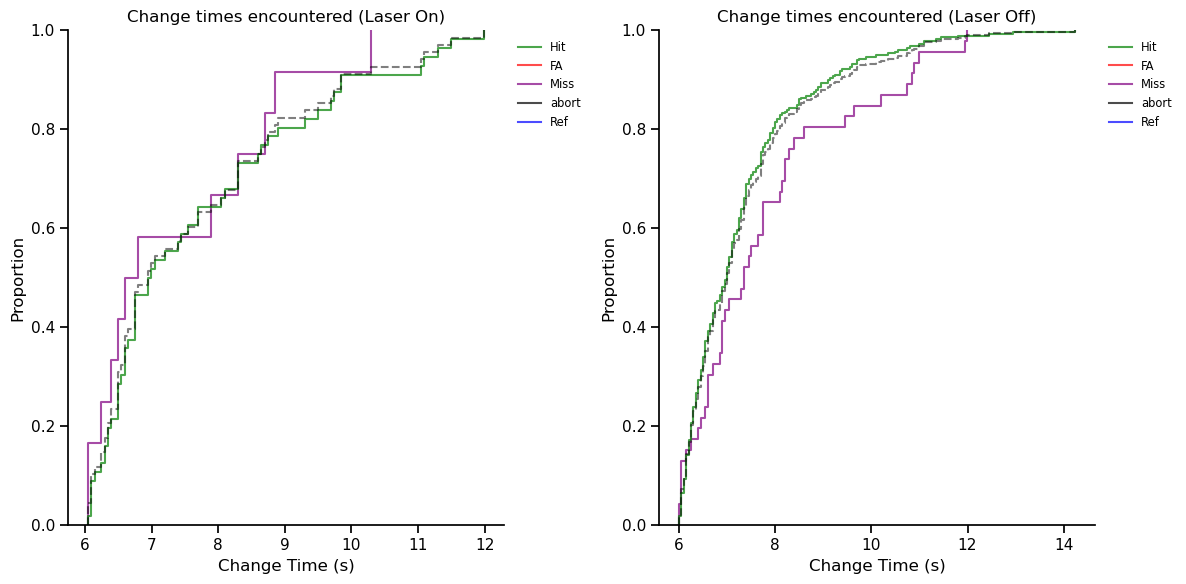

In [20]:
plot_change_encountered_ecdf(session_data, outcome_palette)

### HIT REACTION TIMES BY CHANGE SIZE AS A FUNCTION OF TRIAL PROGRESSION

In [135]:
def plot_session_progession_hit_reaction_time(session_data, bin_size=50):
    # Filter the DataFrame for 'Hit' outcomes
    hit_df = session_data[session_data['outcomes'] == 'Hit'].copy()
    
    # Use the DataFrame index as 'trial_progression'
    hit_df['trial_progression'] = hit_df.index
    
    # Create bins for trial_progression
    hit_df['trial_bin'] = hit_df['trial_progression'] // bin_size
    
    # Calculate the midpoint of each bin
    hit_df['bin_midpoint'] = hit_df['trial_bin'] * bin_size + bin_size / 2
    
    # Group by bin_midpoint and change_sizes_TF and compute mean and standard error
    bin_stats = hit_df.groupby(['bin_midpoint', 'change_sizes_TF'])['reaction_times'].agg(['mean', 'sem']).reset_index()
    
    # Create a custom color palette using magma colormap
    unique_change_sizes = len(hit_df['change_sizes_TF'].unique())
    palette = sns.color_palette("magma", unique_change_sizes)
    
    # Plot using sns.lineplot
    # plt.figure(figsize=(8, 4))
    sns.lineplot(data=bin_stats, x='bin_midpoint', y='mean', hue='change_sizes_TF', palette=palette, marker='o',errorbar=('ci',95), err_style='bars')
    
    # Customize the plot
    plt.title('Hit Reaction Time vs. Trial Progression')
    plt.xlabel('Session progression (Trial Number)')
    plt.ylabel('Mean Reaction Time')
    plt.legend(title='Change Sizes', loc='upper right', bbox_to_anchor=(1.5, 1), frameon=False, fontsize='x-small')
    sns.despine()
    # plt.tight_layout()
    # plt.show()

c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-

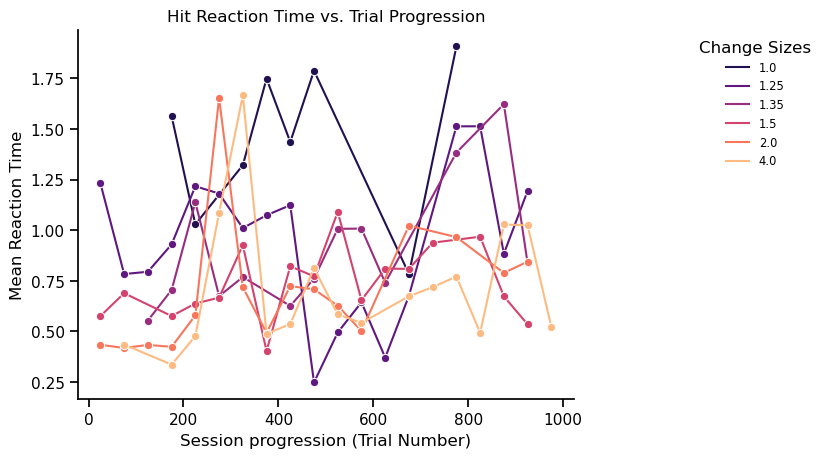

In [136]:
plot_session_progession_hit_reaction_time(session_data, bin_size=50)

### FA REACTION TIMES BY CHANGE SIZE AS A FUNCTION OF TRIAL PROGRESSION

In [137]:
def plot_session_progession_fa_reaction_time(session_data, bin_size=50):
    # Filter the DataFrame for 'FA' outcomes
    fa_df = session_data[session_data['outcomes'] == 'FA'].copy()
    fa_df = fa_df[fa_df['reaction_times'] > 3]
    # Use the DataFrame index as 'trial_progression'
    fa_df['trial_progression'] = fa_df.index
    
    # Create bins for trial_progression
    fa_df['trial_bin'] = fa_df['trial_progression'] // bin_size
    
    # Calculate the midpoint of each bin
    fa_df['bin_midpoint'] = fa_df['trial_bin'] * bin_size + bin_size / 2
    
    # Group by bin_midpoint and change_sizes_TF and compute mean and standard error
    bin_stats = fa_df.groupby(['bin_midpoint', 'change_sizes_TF'])['reaction_times'].agg(['mean', 'sem']).reset_index()
    
    # Create a custom color palette using magma colormap
    unique_change_sizes = len(fa_df['change_sizes_TF'].unique())
    palette = sns.color_palette("magma", unique_change_sizes)
    
    # Plot using sns.lineplot
    # plt.figure(figsize=(8, 4))
    sns.lineplot(data=bin_stats, x='bin_midpoint', y='mean',marker='o', err_style='bars')
    
    # Customize the plot
    plt.title('FA Reaction Time as a Function of Trial Progression')
    plt.xlabel('session progression (Trial Number)')
    plt.ylabel('Mean Reaction Time')
    sns.despine()
    # plt.tight_layout()
    # plt.show()

c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


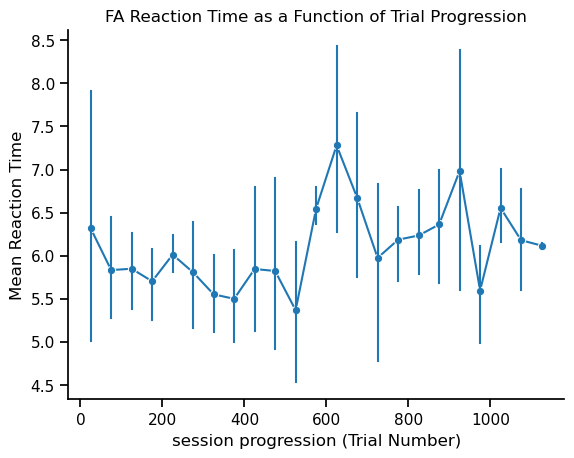

In [96]:
plot_session_progession_fa_reaction_time(session_data, bin_size=50)

### HIT TIME DISTRIBUTION FOR DIFFERENT CHANGE SIZES

In [26]:
def plot_hit_time_distributions(session_data):
    hit_df = session_data[session_data['outcomes'] == 'Hit']
    # Create a custom color palette using magma colormap
    unique_change_sizes = len(hit_df['change_sizes_TF'].unique())
    palette = sns.color_palette("magma", unique_change_sizes)
    sns.kdeplot(data=hit_df, x='reaction_times', hue = 'change_sizes_TF', palette=palette,  fill = True, alpha = 0.2, bw_adjust = 1.0)#, height = 5, aspect = 1.5)
    plt.xlim(0,2.15)
    plt.xlabel('Reaction Time (s)')
    plt.title('Hit Reaction Time Distribution')
    sns.move_legend(plt.gca(), loc = 'upper right',bbox_to_anchor=(1, 1),fontsize = 'x-small', frameon=False, title = 'Change Sizes')
    sns.despine()
    # plt.show()

### ORGANIZE PLOTS IN A GRID (and save figure in cwd folder)

c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\seaborn\_oldcore.py:1119: Fut

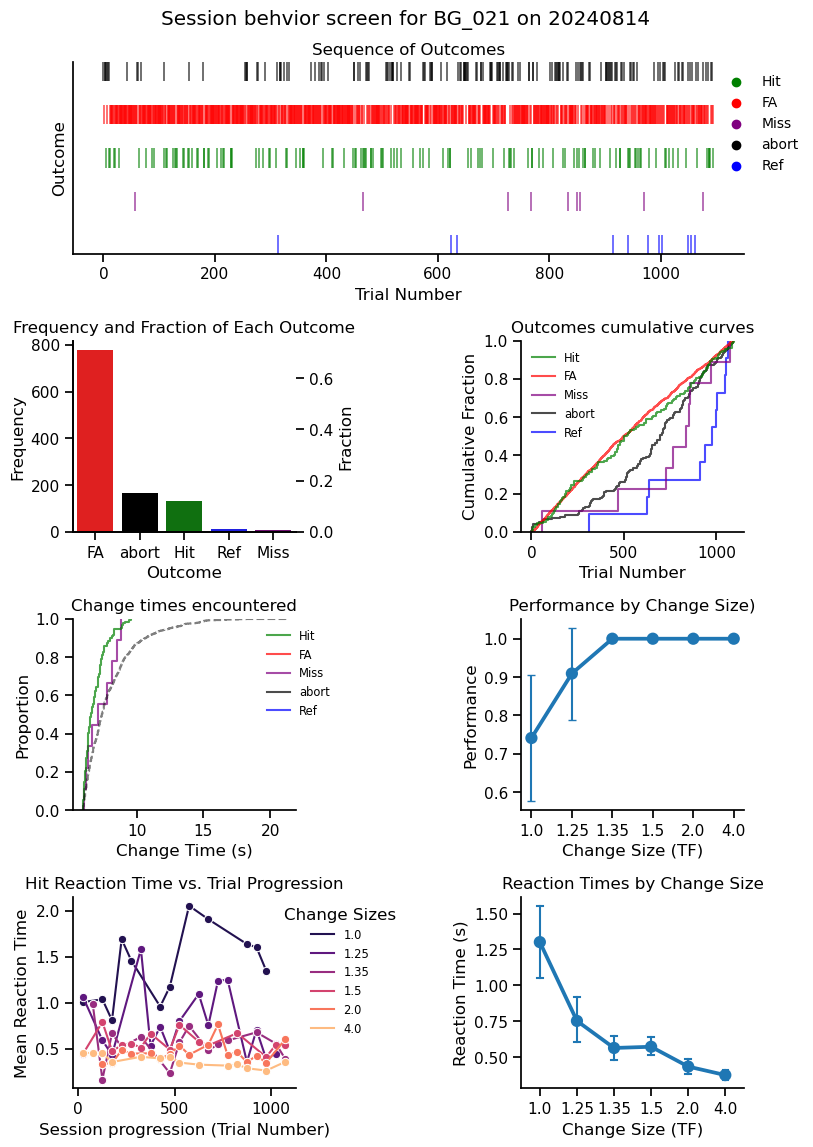

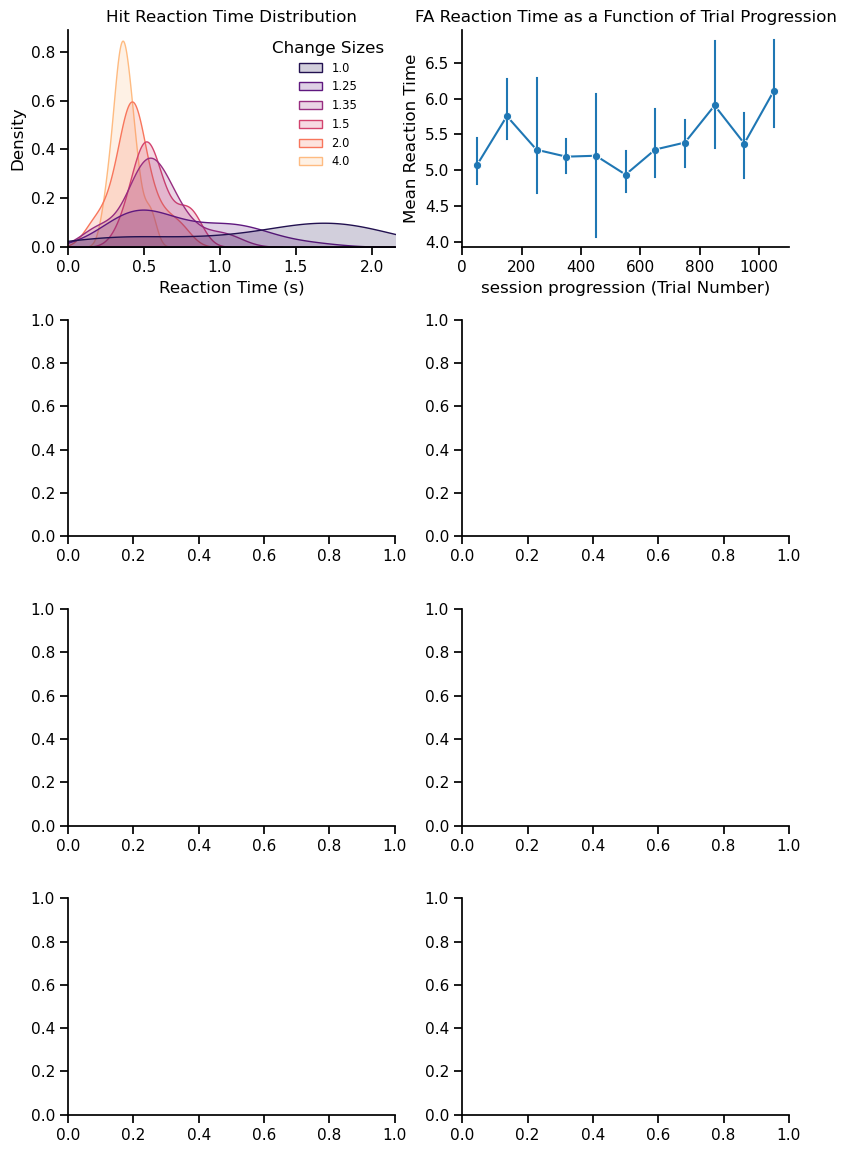

In [27]:
def plot_session_behavior_screen(session_data, outcome_palette):    
    mouse_id = 'BG_' + session_data['mouse_id'][0]
    session_timestamp = session_data['session_date'][0]
    from matplotlib.gridspec import GridSpec
    from matplotlib.backends.backend_pdf import PdfPages
    ### PAGE 1 OF FIGURE (AND EXPORTED .pdf)
    # Create a larger figure with multiple subplots
    fig = plt.figure(figsize=(8.27, 11.69))  # A4 size in inches (8.27 x 11.69)
    gs = GridSpec(4, 2, figure=fig)



    ax1 = fig.add_subplot(gs[0,:])
    ax2 = fig.add_subplot(gs[1,0])
    ax3 = fig.add_subplot(gs[1,1])
    ax4 = fig.add_subplot(gs[2,0])
    ax5  =fig.add_subplot(gs[2,1])
    ax6 = fig.add_subplot(gs[3,0])
    ax7 = fig.add_subplot(gs[3,1])

    # plot into the grid of page 1:
    plt.sca(ax1)
    plot_outcome_sequence(session_data)
    plt.sca(ax2)
    plot_outcome_distribution(ax2,session_data, outcome_palette)
    plt.sca(ax3)
    plot_cumulative_outcome_curve(session_data, outcome_palette)
    plt.sca(ax4)
    plot_change_encountered_ecdf(session_data, outcome_palette)
    plt.sca(ax5)
    plot_session_performance(session_data)
    plt.sca(ax6)
    plot_session_progession_hit_reaction_time(session_data)
    plt.sca(ax7)
    plot_hit_change_size_reaction_times(session_data)

    fig2 = plt.figure(figsize=(8.27, 11.69))  # A4 size in inches (8.27 x 11.69)
    gs_2 = GridSpec(4, 2, figure=fig2)

    ax8 = fig2.add_subplot(gs_2[0,0])
    ax9 = fig2.add_subplot(gs_2[0,1])
    ax10 = fig2.add_subplot(gs_2[1,0])
    ax11 = fig2.add_subplot(gs_2[1,1])
    ax12 = fig2.add_subplot(gs_2[2,0])
    ax13 = fig2.add_subplot(gs_2[2,1])
    ax14 = fig2.add_subplot(gs_2[3,0])
    ax15 = fig2.add_subplot(gs_2[3,1])

    # plot into the grid of page 2:
    plt.sca(ax8)
    plot_hit_time_distributions(session_data)
    plt.sca(ax9)
    plot_session_progession_fa_reaction_time(session_data, bin_size=100)

    fig.suptitle(f'Session behvior screen for {mouse_id} on {session_timestamp}')
    # Adjust layout to fit everything nicely
    fig.tight_layout() #(pad = 2.0)
    # fig.subplots_adjust(hspace=0.3)
    fig2.tight_layout() #(pad = 2.0)

    # Save or display the figure
    with PdfPages(f'session_behvior_screen_mouse_{mouse_id}_{session_timestamp}.pdf') as pdf:
        pdf.savefig(fig)
        pdf.savefig(fig2)

    plt.show()  # Display the figure
    
# Example usage:
plot_session_behavior_screen(session_data, outcome_palette)